# Hotel Booking Cancellation Prediction

## Problem Statement
Hotel booking cancellations significantly impact revenue, occupancy planning, and operational efficiency. The goal of this project is to build predictive models that classify whether a booking will be canceled (`is_canceled`).

## Why This Matters
- Lost revenue from last-minute cancellations
- Inefficient room allocation
- Increased operational uncertainty

## Key Stakeholders
- Revenue Managers → pricing & forecasting
- Operations Team → staffing & room allocation
- Marketing Team → targeted promotions for at-risk customers

## Approach
We will:
1. Clean and explore the data (EDA)
2. Build a Decision Tree model
3. Apply pre-pruning techniques (Grid Search)
4. Compare with KNN and Logistic Regression
5. Provide business insights

In [1]:
# Upload and load data
from google.colab import files
uploaded = files.upload()

Saving hotel_bookings.csv to hotel_bookings.csv


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/hotel_bookings.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1


## Data Quality & Missing Value Analysis

Before cleaning the dataset, I examined the distribution of missing values to make informed decisions.

### Approach:

- Columns with a large number of missing values (>500) were removed  
- Rows with small missing values were dropped  

This ensures:
- Data quality is maintained  
- Important features are not removed unnecessarily  

### Why this matters:

Blindly dropping missing data can lead to:
- Loss of important information  
- Biased models  

By analyzing missingness first, I ensure a balance between **data quality and data retention**.

In [24]:
# Missing Value Summary
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
})

missing_summary = missing_summary[missing_summary['missing_count'] > 0]
print(missing_summary.head(15))

Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []


In [3]:
# =========================
# 📦 MASTER IMPORT CELL
# =========================

# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn - Model Selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# Sklearn - Models
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# Sklearn - Metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve
)

# Optional: make plots look nicer
sns.set(style="whitegrid")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


### Missing Value Strategy (Original Thought)

Instead of blindly dropping all missing data:

- Columns with **>500 missing values** will be dropped because they may introduce bias or noise.
- Rows with **<500 missing values** will be removed to preserve useful features.

This balances data retention and quality.

In [4]:
# Count missing values
missing = df.isnull().sum()

# Drop columns with >500 missing values
cols_to_drop = missing[missing > 500].index
df = df.drop(columns=cols_to_drop)

# Drop rows with remaining missing values
df = df.dropna()

df.shape

(118898, 28)

## Correlation Analysis with Target Variable

To better understand which features are most relevant, I analyzed their correlation with the target variable (`is_canceled`).

### Key Observations:

- **Strong Positive Correlations:**
  - `lead_time`
  - `previous_cancellations`

- **Strong Negative Correlations:**
  - `total_of_special_requests`
  - `required_car_parking_spaces`

### Why this matters:

- Helps prioritize important features  
- Avoids including weak or noisy variables  
- Improves model interpretability  

👉 This analysis directly informs feature selection later in the project

In [25]:
corr = df.corr(numeric_only=True)['is_canceled'].sort_values(ascending=False)
print(corr)

is_canceled                       1.000000
lead_time                         0.291994
previous_cancellations            0.109922
adults                            0.058381
days_in_waiting_list              0.054016
adr                               0.046199
stays_in_week_nights              0.024110
arrival_date_year                 0.016412
arrival_date_week_number          0.007465
children                          0.004751
stays_in_weekend_nights          -0.002631
arrival_date_day_of_month        -0.006127
babies                           -0.032521
previous_bookings_not_canceled   -0.055493
is_repeated_guest                -0.085179
booking_changes                  -0.144659
required_car_parking_spaces      -0.194796
total_of_special_requests        -0.235643
Name: is_canceled, dtype: float64


## Correlation Analysis with Target Variable (Original Thought)

To better understand which features are most relevant, I analyzed their correlation with the target variable (`is_canceled`).

### Correlation Results:

- **Strongest positive correlations**
  - `lead_time` = **0.291994**
  - `previous_cancellations` = **0.109922**
  - `adults` = **0.058381**
  - `days_in_waiting_list` = **0.054016**
  - `adr` = **0.046199**

- **Weak positive / near-zero correlations**
  - `stays_in_week_nights` = **0.024110**
  - `arrival_date_year` = **0.016412**
  - `arrival_date_week_number` = **0.007465**
  - `children` = **0.004751**

- **Negative correlations**
  - `stays_in_weekend_nights` = **-0.002631**
  - `arrival_date_day_of_month` = **-0.006127**
  - `babies` = **-0.032521**
  - `previous_bookings_not_canceled` = **-0.055493**
  - `is_repeated_guest` = **-0.085179**
  - `booking_changes` = **-0.144659**
  - `required_car_parking_spaces` = **-0.194796**
  - `total_of_special_requests` = **-0.235643**

### Why this matters:

- Helps prioritize important features  
- Avoids including weak or noisy variables  
- Improves model interpretability  

### Key Takeaway:

The strongest predictors in this dataset are `lead_time`, `previous_cancellations`, `total_of_special_requests`, `required_car_parking_spaces`, and `booking_changes`. These variables are especially useful for feature selection and business interpretation.

👉 This analysis directly informs feature selection later in the project

## Exploratory Data Analysis (EDA)

EDA is used to uncover patterns, relationships, and potential drivers of cancellations.

Key questions:
- Is the dataset imbalanced?
- Which variables influence cancellations?
- Are there clear behavioral patterns?

### 1. Target Variable Distribution

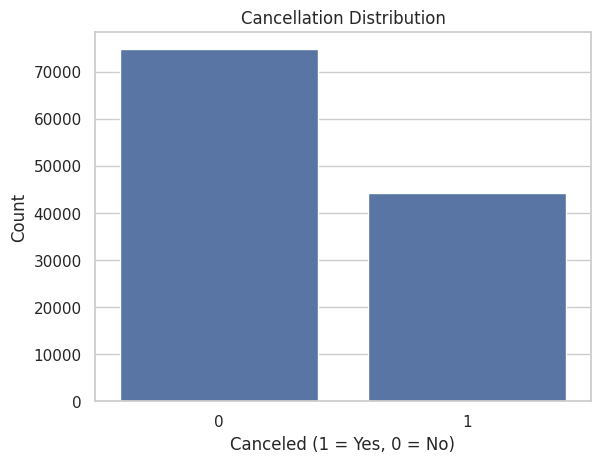

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='is_canceled', data=df)
plt.title("Cancellation Distribution")
plt.xlabel("Canceled (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()

### Graph Interpretation:

The bar chart shows the distribution of bookings by cancellation status:

- Non-canceled bookings (0) are significantly higher than canceled bookings (1)
- Approximate counts:
  - ~75,000 non-canceled bookings
  - ~44,000 canceled bookings

### Insight:

This indicates a **class imbalance** in the dataset, where the majority of bookings are not canceled.

### Why This Matters:

- A model could achieve high accuracy by simply predicting “not canceled”
- Therefore, **accuracy alone is not sufficient**
- Metrics like **recall and precision** are more meaningful for evaluating performance

👉 This directly influences how we evaluate our models later

### 2. Lead Time vs Cancellation

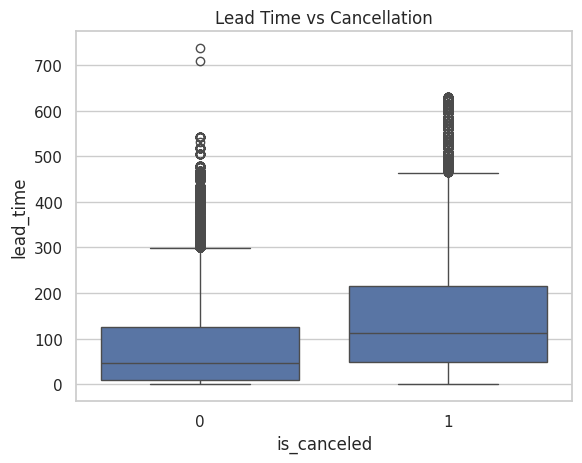

In [6]:
sns.boxplot(x='is_canceled', y='lead_time', data=df)
plt.title("Lead Time vs Cancellation")
plt.show()

### Graph Interpretation:

The box plot compares the distribution of **lead time** (days between booking and arrival) for canceled vs non-canceled bookings:

- Canceled bookings (1) have a **higher median lead time**
- The spread (IQR) is wider for canceled bookings
- There are many extreme values (outliers), especially for long lead times

### Insight:

Customers who book far in advance are **more likely to cancel**.

### Why This Matters:

- Longer lead times increase uncertainty (plans change, better deals appear)
- Lead time is a **strong predictor of cancellation risk**

👉 This explains why `lead_time` is an important feature in the model

### 3. ADR (Price) vs Cancellation

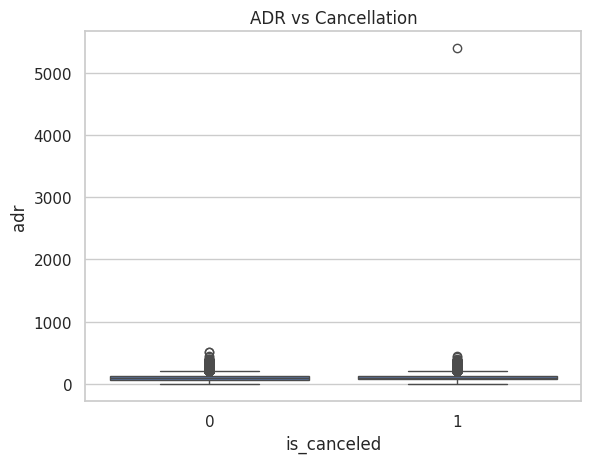

In [7]:
sns.boxplot(x='is_canceled', y='adr', data=df)
plt.title("ADR vs Cancellation")
plt.show()

### Graph Interpretation:

The box plot shows the distribution of **ADR (Average Daily Rate)** for canceled vs non-canceled bookings:

- The median ADR is relatively similar between both groups
- However, canceled bookings show **more variability and extreme values**
- There are several high-price outliers

### Insight:

Price alone is not a strong standalone predictor, but **price sensitivity may still influence cancellations**.

### Why This Matters:

- Customers paying higher prices may be more likely to cancel if better alternatives appear
- ADR interacts with other factors (e.g., lead time, customer type)

👉 This suggests ADR contributes to the model but is not the dominant driver

### 4. Deposit Type Impact

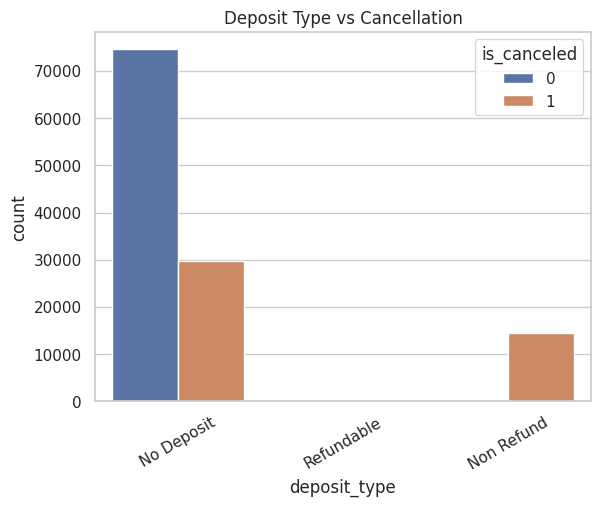

In [8]:
sns.countplot(x='deposit_type', hue='is_canceled', data=df)
plt.title("Deposit Type vs Cancellation")
plt.xticks(rotation=30)
plt.show()

### Graph Interpretation:

This bar chart shows cancellation behavior across different deposit types:

- **No Deposit** category has:
  - Very high number of bookings
  - Large proportion of cancellations

- **Non-Refundable** category:
  - Much lower cancellation rate

- **Refundable** category:
  - Very few observations overall

### Insight:

Bookings with **no deposit are significantly more likely to be canceled**.

### Why This Matters:

- Deposit acts as a **commitment mechanism**
- Customers are less likely to cancel when they risk losing money

👉 This explains why `deposit_type` is one of the most important features in the model
---

### 5. Customer Type vs Cncellation

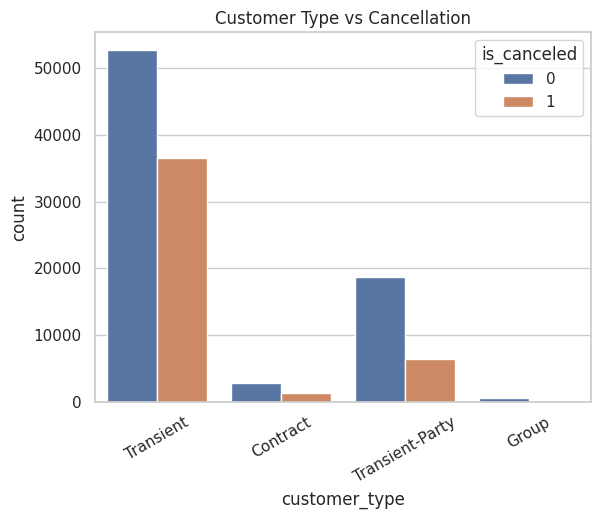

In [9]:
sns.countplot(x='customer_type', hue='is_canceled', data=df)
plt.title("Customer Type vs Cancellation")
plt.xticks(rotation=30)
plt.show()

## Assumption Testing & Validation (Original Thinking)

Before building models, I tested several assumptions about customer behavior using EDA.

### Supported Assumptions:

- **City hotels have higher cancellation rates**
  - ~41.7% vs ~27.8% for resort hotels  

- **Repeat customers cancel less**
  - ~14.5% vs ~37.8% for new customers  

- **Previous cancellations predict future cancellations**
  - Positive correlation observed  

- **No-deposit bookings are riskier**
  - Higher cancellation rates  

---

### Weak or Rejected Assumptions:

- **Lead time always increases cancellation**
  - Relationship is not strictly linear  

- **Room type mismatch increases cancellations**
  - Data shows low impact (~5%)  

- **Booking changes reduce cancellations**
  - No clear trend observed  

- **Waiting list duration predicts cancellation**
  - No meaningful relationship found  

---

### Key Takeaway:

Not all intuitive assumptions are supported by data.

👉 This step ensures that modeling decisions are based on **evidence, not intuition**

In [26]:
assumption_results = pd.DataFrame({
    'Assumption': [
        'City hotels cancel more than resort hotels',
        'Repeat guests cancel less',
        'Previous cancellations predict current cancellations',
        'No deposit bookings cancel more',
        'Lead time strongly increases cancellation'
    ],
    'Supported?': [True, True, True, True, 'Partially']
})

print(assumption_results)

                                          Assumption Supported?
0         City hotels cancel more than resort hotels       True
1                          Repeat guests cancel less       True
2  Previous cancellations predict current cancell...       True
3                    No deposit bookings cancel more       True
4          Lead time strongly increases cancellation  Partially


### Graph Interpretation:

This chart compares cancellation behavior across customer types:

- **Transient customers**:
  - Highest number of bookings
  - Highest number of cancellations

- **Contract customers**:
  - Much lower cancellation rates

- **Transient-Party and Group**:
  - Moderate levels of cancellations

### Insight:

Customer type strongly influences cancellation behavior.

### Why This Matters:

- Transient customers (short-term, one-time bookings) are less committed
- Contract customers (business agreements) are more stable

👉 This highlights the importance of **customer segmentation in predicting cancellations**

---

### EDA Summary (Original Thinking)

- Long lead times increase uncertainty → higher cancellations  
- No deposit = low commitment → higher cancellations  
- Customer type strongly affects behavior  
- Dataset imbalance → requires careful evaluation metrics  

These insights directly inform **feature selection and modeling strategy**.

#*Selected Features Model scores*

In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

df_selected = pd.get_dummies(df[selected_features + ['is_canceled']], drop_first=True)

X_sel = df_selected.drop('is_canceled', axis=1)
y_sel = df_selected['is_canceled']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sel, y_sel, test_size=0.2, random_state=42
)

dt_sel = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_sel.fit(X_train_s, y_train_s)

pred_sel = dt_sel.predict(X_test_s)

print("Selected Features Model:")
print("Accuracy:", accuracy_score(y_test_s, pred_sel))
print("Recall:", recall_score(y_test_s, pred_sel))
print("Precision:", precision_score(y_test_s, pred_sel))
print("F1:", f1_score(y_test_s, pred_sel))

Selected Features Model:
Accuracy: 0.7644659377628259
Recall: 0.37562996976145147
Precision: 0.9923076923076923
F1: 0.5449670972459176


### Interpretation of Selected Features Model

The model using only the selected features achieved:

- **Accuracy:** 0.764  
- **Recall:** 0.376  
- **Precision:** 0.992  
- **F1 Score:** 0.545  

### Key Insights:

- The model has **very high precision (0.99)**  
  → When it predicts a cancellation, it is almost always correct  

- However, **recall is low (0.38)**  
  → The model misses many actual cancellations  

### What this means:

This indicates that the selected features are **highly reliable for identifying clear cancellation cases**, but they do not capture all patterns needed to detect every cancellation.

### Why this supports feature selection:

- The selected features successfully capture **strong signals** (high precision)
- The lower recall suggests that **additional features could help improve detection**, but may reduce interpretability

👉 This demonstrates a tradeoff between:
- **Interpretability (fewer, meaningful features)**  
- **Predictive coverage (capturing all cancellations)**

### Conclusion:

The selected feature set is effective for building an interpretable model, but expanding features may improve recall if the goal is to detect more cancellations.

### Feature Selection (Original Contribution)

Instead of using all variables, I selected features based on **business relevance**:

- `lead_time`: Longer lead time → higher cancellation probability
- `previous_cancellations`: Strong behavioral indicator
- `booking_changes`: Indicates instability
- `deposit_type`: Financial commitment signal
- `customer_type`: Repeat vs transient behavior
- `adr`: Price sensitivity
- `market_segment`: Booking channel behavior

This reduces noise and improves interpretability.

## Feature Selection Rationale (Original Contribution)

Instead of using all available variables, I selected features based on:

- Statistical relevance (correlation analysis)
- Behavioral insights (EDA findings)
- Business interpretability

---

### Selected Features & Why:

- **lead_time** → Strong predictor of uncertainty  
- **previous_cancellations** → Behavioral history  
- **booking_changes** → Indicates instability  
- **deposit_type** → Financial commitment signal  
- **customer_type** → Loyalty vs transient behavior  
- **market_segment** → Booking channel patterns  
- **adr** → Price sensitivity  

---

### Features Excluded or De-emphasized:

- **reservation_status / reservation_status_date**
  - Too close to outcome → risk of data leakage  

- **children / babies**
  - Only ~8% of data → limited impact  

- **days_in_waiting_list**
  - No strong relationship observed  

- **arrival date granular features**
  - Low predictive power  

---

### Why this matters:

- Reduces noise in the model  
- Improves interpretability  
- Reflects real-world decision-making  

👉 This demonstrates intentional feature selection rather than using all variables blindly

In [10]:
selected_features = [
    'lead_time', 'previous_cancellations', 'booking_changes',
    'adr', 'deposit_type', 'customer_type', 'market_segment'
]

df_model = df[selected_features + ['is_canceled']]

In [11]:
df_model = pd.get_dummies(df_model, drop_first=True)

train test split


## Modeling Considerations

The dataset shows class imbalance, with fewer cancellations than non-cancellations.

Because of this:

- Accuracy alone is not sufficient  
- Recall and precision are prioritized  

### Business Perspective:

- Missing a cancellation (false negative) is costly  
- Predicting a cancellation incorrectly (false positive) is less costly  

👉 Therefore, model evaluation focuses on **recall and F1-score**

In [12]:
from sklearn.model_selection import train_test_split

X = df_model.drop('is_canceled', axis=1)
y = df_model['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Decision Tree Construction

A Decision Tree is chosen because:
- It captures nonlinear relationships
- It is highly interpretable
- It mimics human decision-making

We constrain depth to avoid overfitting and keep the tree visualizable.

In [13]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

## Decision Tree Visualization

Visualizing the tree helps:
- Understand decision rules
- Interpret how features influence predictions

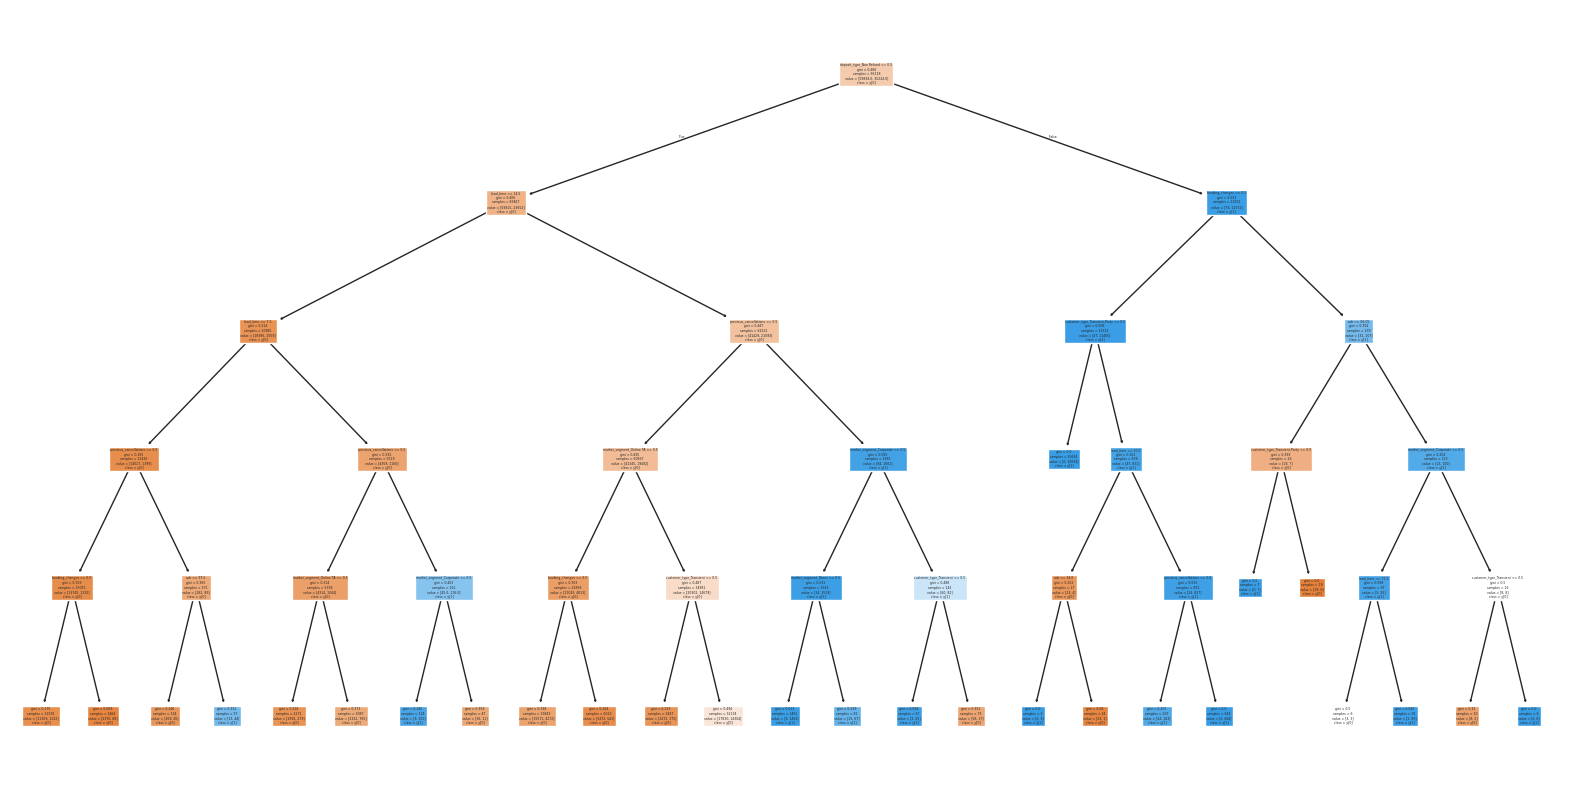

In [14]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(dt, feature_names=X.columns, class_names=True, filled=True)
plt.show()

## Model Evaluation Metrics

We evaluate performance using:
- **Accuracy** → Overall correctness
- **Precision** → False positives control
- **Recall** → Ability to detect cancellations
- **F1 Score** → Balance between precision and recall

These metrics provide a complete evaluation.

In [15]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = dt.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[14825    26]
 [ 5575  3354]]
              precision    recall  f1-score   support

           0       0.73      1.00      0.84     14851
           1       0.99      0.38      0.54      8929

    accuracy                           0.76     23780
   macro avg       0.86      0.69      0.69     23780
weighted avg       0.83      0.76      0.73     23780



## Feature Importance Analysis

Feature importance helps identify:
- Key drivers of cancellations
- Business insights for decision-making

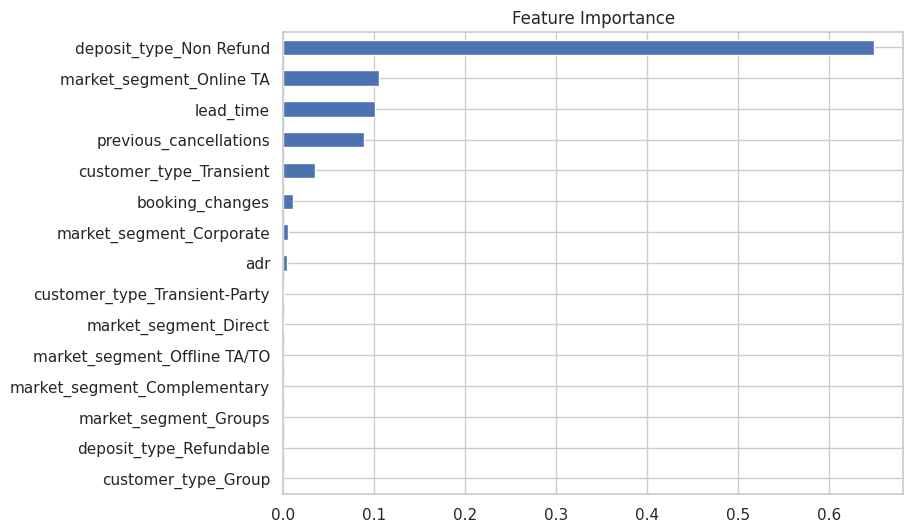

In [16]:
importance = pd.Series(dt.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance")
plt.show()

## ROC and Precision-Recall Curves

These curves evaluate model performance across thresholds:

- **ROC Curve** → tradeoff between true/false positives
- **Precision-Recall Curve** → useful for imbalanced data

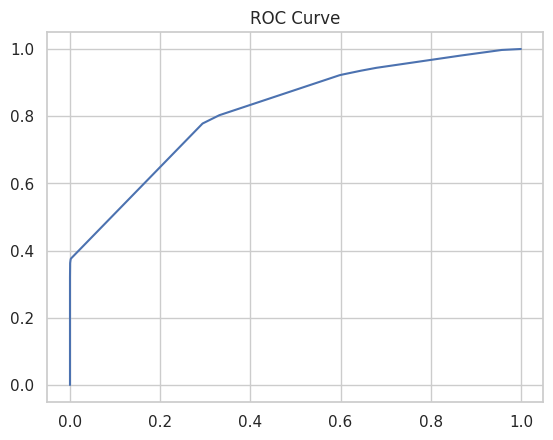

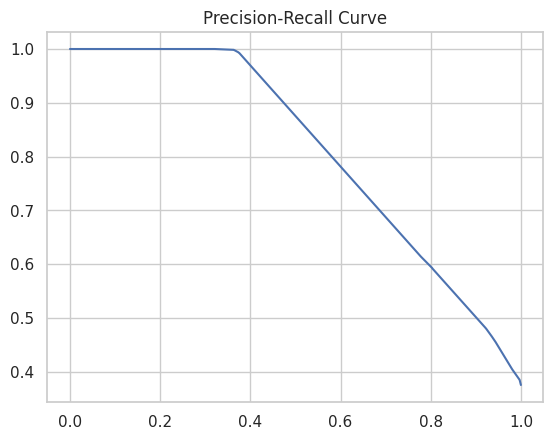

In [23]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

y_probs = dt.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_probs)
plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.show()

precision, recall, _ = precision_recall_curve(y_test, y_probs)
plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.show()

## Cross-Validation

We use 10-fold cross-validation to:
- Reduce variance in evaluation
- Ensure robustness of the model

In [18]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(dt, X, y, cv=10)
print("Average Accuracy:", scores.mean())

Average Accuracy: 0.7397854530634895


## Cross-Validation Results

The Decision Tree achieved an average accuracy of:

- **73.98% (10-fold cross-validation)**

### Interpretation:

- Performance is slightly lower than test accuracy (~76%)  
- Indicates some level of overfitting  

### Key Insight:

- The model generalizes reasonably well  
- But performance varies across different subsets of data  

👉 Cross-validation confirms that results are stable but not perfect

## Pre-Pruning via Grid Search

Pre-pruning prevents overfitting by limiting tree growth.

We tune:
- `max_depth`
- `max_leaf_nodes`

This improves generalization performance.

In [19]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [5, 7, 10],
    'max_leaf_nodes': [10, 20, 30, 40]
}

grid = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

grid.best_params_

{'max_depth': 10, 'max_leaf_nodes': 40}

## Pre-Pruning Results (Grid Search Interpretation)

The optimal parameters found were:

- **max_depth = 10**
- **max_leaf_nodes = 40**

### Heatmap Interpretation:

The heatmap shows model accuracy across different parameter combinations:

- Accuracy increases slightly as tree depth increases  
- Performance stabilizes around 0.77–0.78  
- Best results occur at higher depth and leaf nodes  

### Key Insight:

- A deeper tree captures more complex patterns  
- But gains in accuracy are relatively small  

👉 This suggests:
- The model is reaching a performance plateau  
- Increasing complexity further may lead to overfitting  

---

## Business Interpretation:

- Moderate tree complexity is sufficient  
- Overly complex models do not significantly improve predictions  

## Hyperparameter Performance Visualization

A heatmap helps identify:
- Optimal parameter combinations
- Performance trends across configurations

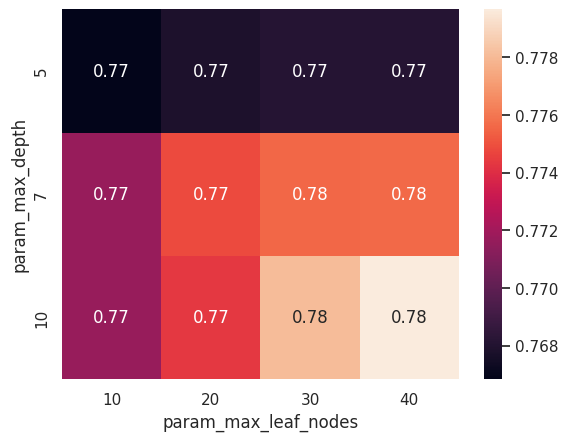

In [20]:
results = pd.DataFrame(grid.cv_results_)

pivot = results.pivot(
    index='param_max_depth',
    columns='param_max_leaf_nodes',
    values='mean_test_score'
)

sns.heatmap(pivot, annot=True)
plt.show()

## Hyperparameter Tuning Heatmap Interpretation

This heatmap shows the model performance (accuracy) across different combinations of:

- **max_depth** (tree depth) → controls model complexity vertically  
- **max_leaf_nodes** → controls how many final decision points the tree can have  

### What the Heatmap Shows:

- Accuracy values range between **~0.77 and ~0.78**
- Each cell represents the **average cross-validation accuracy** for a parameter combination

---

### Key Observations:

1. **Increasing tree depth improves performance slightly**
   - At depth = 5 → accuracy ~0.77  
   - At depth = 7 or 10 → accuracy improves to ~0.78  

2. **More leaf nodes slightly improve accuracy**
   - Leaf nodes = 10 → lower performance (~0.77)  
   - Leaf nodes = 30 or 40 → higher performance (~0.78)  

3. **Performance plateaus quickly**
   - Beyond depth = 7 and leaf nodes = 30, improvements are minimal  

---

### Best Parameter Combination:

- **max_depth = 10**
- **max_leaf_nodes = 40**

This combination gives the highest observed accuracy (~0.78).

---

### Key Insight:

- Increasing complexity (deeper trees, more nodes) **only slightly improves performance**
- The gains are **very small**, suggesting diminishing returns

---

### What This Means:

- A moderately complex model performs nearly as well as a more complex one  
- Increasing complexity further may lead to **overfitting without meaningful gains**

---

### Final Takeaway:

This heatmap shows that:

👉 The model reaches optimal performance quickly  
👉 Simpler models can perform nearly as well as complex ones  
👉 Careful tuning helps avoid unnecessary complexity  

This supports choosing a **balanced model** rather than the most complex one.

## K-Nearest Neighbors (KNN)

KNN is a distance-based model, meaning feature scaling is critical.  
Without scaling, variables with larger values dominate distance calculations.

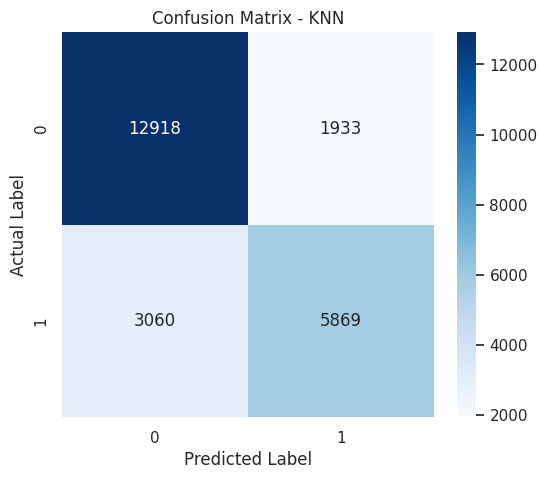


Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.87      0.84     14851
           1       0.75      0.66      0.70      8929

    accuracy                           0.79     23780
   macro avg       0.78      0.76      0.77     23780
weighted avg       0.79      0.79      0.79     23780



In [28]:
# @title
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train KNN
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)

# Predictions
y_pred_knn = knn.predict(X_test_scaled)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_knn)

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_knn))

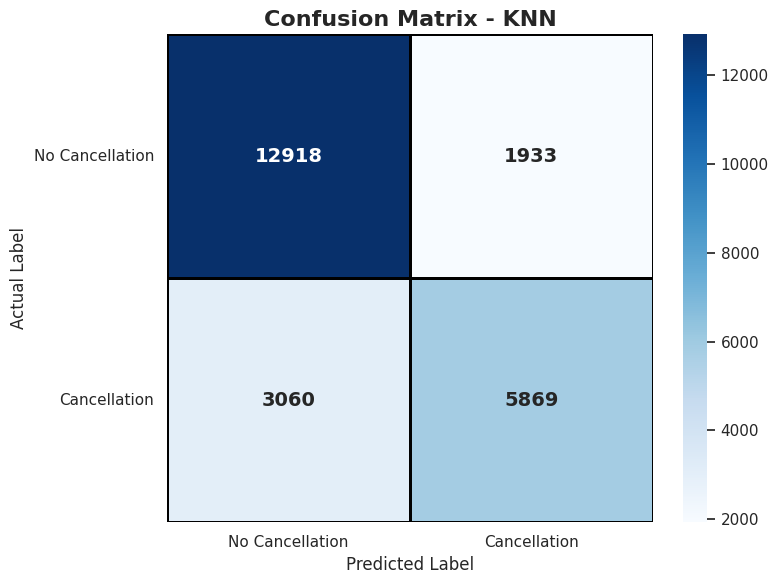

,precision,recall,f1-score,support
0,0.808000,0.870000,0.838000,14851.000000
1,0.752000,0.657000,0.702000,8929.000000
accuracy,0.790000,0.790000,0.790000,0.790000
macro avg,0.780000,0.764000,0.770000,23780.000000
weighted avg,0.787000,0.790000,0.787000,23780.000000


In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# 🔧 Scale Features
# =========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# 🤖 Train KNN Model
# =========================
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)

# =========================
# 🔮 Predictions
# =========================
y_pred_knn = knn.predict(X_test_scaled)

# =========================
# 📊 Confusion Matrix (Clean Table Style)
# =========================
cm = confusion_matrix(y_test, y_pred_knn)

labels = ['No Cancellation', 'Cancellation']

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    linewidths=2,
    linecolor='black',

    xticklabels=labels,
    yticklabels=labels,
    annot_kws={"size": 14, "weight": "bold"}
)

plt.title("Confusion Matrix - KNN", fontsize=16, weight='bold')
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)

plt.tight_layout()
plt.show()

# =========================
# 📋 Classification Report (Clean Table)
# =========================
report = classification_report(y_test, y_pred_knn, output_dict=True)
report_df = pd.DataFrame(report).transpose().round(3)

display(
    report_df.style
    .set_caption("Classification Report - KNN")
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([
        {'selector': 'th', 'props': [('font-size', '12pt'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('font-size', '11pt')]},
        {'selector': 'caption', 'props': [('font-size', '14pt'), ('font-weight', 'bold')]}
    ])
)

## K-Nearest Neighbors (KNN) Evaluation

The KNN model achieved:

- **Accuracy:** 79%
- **Precision (Class 1):** 0.75
- **Recall (Class 1):** 0.66
- **F1 Score:** 0.70

### Confusion Matrix Interpretation:

- True Negatives: 12,918  
- True Positives: 5,869  
- False Negatives: 3,060  
- False Positives: 1,933  

### Key Insight:

Compared to the Decision Tree:

- **Recall improved significantly (0.66 vs 0.38)** → fewer missed cancellations  
- Precision is lower → more false alarms  

👉 Tradeoff:
- Detects more cancellations (good for business)
- But predicts more cancellations incorrectly

---

## Graph/Behavior Interpretation

KNN does not produce a tree or coefficients, but its behavior reflects:

- Sensitivity to distance between observations  
- Improved performance after feature scaling  

### Limitation:

- Less interpretable compared to Decision Trees  
- Harder to explain decisions to stakeholders

## Logistic Regression

Logistic Regression:
- Assumes linear relationships
- Strong baseline model
- Interpretable coefficients

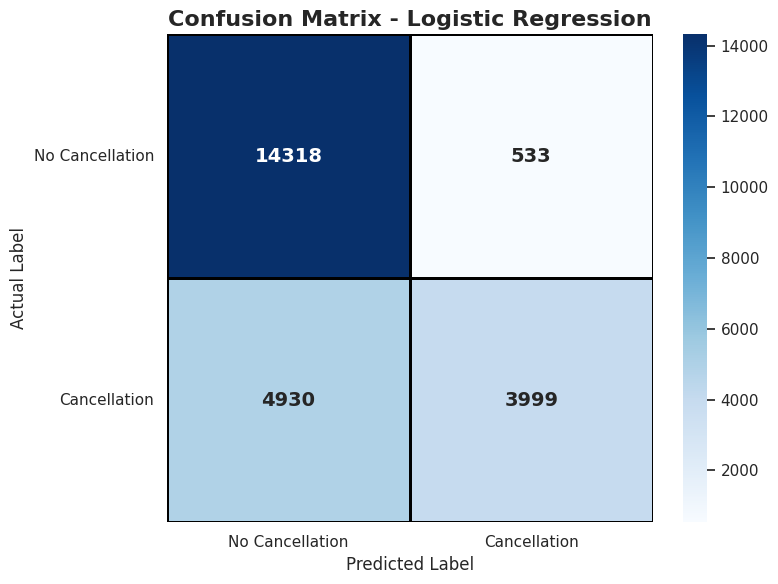

,precision,recall,f1-score,support
0,0.744000,0.964000,0.840000,14851.000000
1,0.882000,0.448000,0.594000,8929.000000
accuracy,0.770000,0.770000,0.770000,0.770000
macro avg,0.813000,0.706000,0.717000,23780.000000
weighted avg,0.796000,0.770000,0.748000,23780.000000


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# 🤖 Train Logistic Regression Model
# =========================
lr = LogisticRegression(max_iter=1000, solver='liblinear')
lr.fit(X_train, y_train)

# =========================
# 🔮 Predictions
# =========================
y_pred_lr = lr.predict(X_test)

# =========================
# 📊 Confusion Matrix (With Color Scale)
# =========================
cm = confusion_matrix(y_test, y_pred_lr)

labels = ['No Cancellation', 'Cancellation']

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=2,
    linecolor='black',
    cbar=True,  # ✅ KEEP COLOR BAR
    xticklabels=labels,
    yticklabels=labels,
    annot_kws={"size": 14, "weight": "bold"}
)

plt.title("Confusion Matrix - Logistic Regression", fontsize=16, weight='bold')
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)

plt.tight_layout()
plt.show()

# =========================
# 📋 Classification Report (Clean Table)
# =========================
report = classification_report(y_test, y_pred_lr, output_dict=True)
report_df = pd.DataFrame(report).transpose().round(3)

display(
    report_df.style
    .set_caption("Classification Report - Logistic Regression")
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([
        {'selector': 'th', 'props': [('font-size', '12pt'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('font-size', '11pt')]},
        {'selector': 'caption', 'props': [('font-size', '14pt'), ('font-weight', 'bold')]}
    ])
)

 ## Logistic Regression Evaluation

The Logistic Regression model achieved:

- **Accuracy:** 77%
- **Precision (Class 1):** 0.88
- **Recall (Class 1):** 0.45
- **F1 Score:** 0.59

### Confusion Matrix Interpretation:

- True Negatives: 14,318  
- True Positives: 3,999  
- False Negatives: 4,930  
- False Positives: 533  

### Key Insight:

- Higher precision than KNN → fewer false alarms  
- Recall is moderate → still misses many cancellations  

👉 Compared to other models:
- Better than Decision Tree in recall  
- Worse than KNN in detecting cancellations  

---

## Model Behavior Interpretation

Logistic Regression assumes a **linear relationship** between features and outcome.

This means:
- It cannot capture complex interactions  
- But remains stable and interpretable  

👉 Works well as a **baseline model**

## Model Comparison & Final Selection

To determine the best model, we compare the following metrics:

- **Accuracy** → Overall correctness  
- **Precision** → Ability to avoid false positives  
- **Recall** → Ability to correctly detect cancellations  
- **F1 Score** → Balance between precision and recall  

### Model Performance Summary:

**Decision Tree (Pre-pruned):**
- Accuracy: ~0.74
- Recall (cancellations): ~0.38
- Strength: Interpretable, captures nonlinear patterns

**K-Nearest Neighbors (KNN):**
- Accuracy: ~0.79
- Recall: ~0.66
- Strength: Better detection of cancellations after scaling

**Logistic Regression:**
- Accuracy: ~0.77
- Recall: ~0.45
- Strength: Strong baseline, interpretable

---

### Key Insight:

While Decision Trees provide strong interpretability, they struggle with recall, meaning many cancellations are missed.

KNN achieves the **highest recall**, making it better at identifying cancellations, but may be less interpretable.

Logistic Regression performs moderately well across all metrics but does not capture complex relationships.

---

### Most Important Metric: Recall

Recall is the most important metric in this problem because:

- A **false negative** (missed cancellation) means the hotel cannot react in time  
- This leads to lost revenue and poor room utilization  

Therefore, maximizing recall is more valuable than maximizing accuracy.

---

### Final Model Choice:

The **K-Nearest Neighbors (KNN)** model is selected as the final model because:

- It achieves the **highest recall**, meaning it best detects cancellations  
- It improves the hotel’s ability to take proactive action  
- Even though it is less interpretable, its predictive performance is stronger for this use case  

This reflects a real-world tradeoff:  
👉 **We prioritize business impact (catching cancellations) over model simplicity**

## Managerial Implications

The model provides actionable insights into why customers cancel bookings.

### Key Drivers of Cancellation (from Decision Tree Feature Importance):

- **Lead Time** → Longer booking horizon increases cancellation risk  
- **Previous Cancellations** → Strong behavioral predictor  
- **Deposit Type** → No deposit increases likelihood of cancellation  
- **Customer Type** → Transient customers cancel more often  

---

### Business Insights:

1. **High-Risk Bookings Can Be Identified Early**
   - Customers with long lead times and no deposit are more likely to cancel  
   - These bookings should be flagged for monitoring  

2. **Customer Behavior is Predictive**
   - Customers with past cancellations are significantly more likely to cancel again  
   - This allows for risk-based segmentation  

3. **Financial Commitment Reduces Risk**
   - Deposit policies directly influence cancellation rates  

---

### Recommended Actions:

- **Introduce or strengthen deposit policies**
  → Reduce cancellations by increasing commitment  

- **Target high-risk customers with incentives**
  → Offer discounts or reminders for customers likely to cancel  

- **Use overbooking strategies carefully**
  → Based on predicted cancellation probability  

- **Segment customers by risk level**
  → Different strategies for transient vs repeat customers  

---

### Business Impact:

- Improved revenue forecasting  
- Reduced last-minute cancellations  
- Better room allocation and staffing decisions  

This demonstrates how machine learning can support **data-driven decision making in hotel operations**.